# Random Forest 模型实验

**数据集**：Give Me Some Credit（信用违约预测）  
**目标变量**：`SeriousDlqin2yrs`（1 = 未来两年内发生严重逾期，0 = 正常）  
**负责模块**：Random Forest

## 实验流程
1. 读取预处理后的训练集与测试集
2. 用 SMOTE 处理类别不平衡（正负样本约 1:14）
3. `StratifiedKFold + GridSearchCV` 超参数调优（以 ROC-AUC 为主指标）
4. 评估两个维度：**准确率**（Accuracy / ROC-AUC / PR-AUC）与**可解释性**（特征重要性 / SHAP 值）
5. 在保留测试集上报告最终 test error

> **关键原则**：测试集在训练和调参阶段全程不可见，仅在最终评估时使用一次。

## 1. 导入库 | Import Libraries

In [9]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_predict
)
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    roc_curve, auc, precision_recall_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

RANDOM_STATE = 42
print('All libraries imported successfully.')

All libraries imported successfully.


## 2. 读取数据 | Load Data

In [10]:
def _find_data_dir():
    """自动定位 data 文件夹，兼容从不同目录启动 notebook 的情况"""
    candidates = [
        os.path.abspath(os.path.join(os.getcwd(), '..', 'data')),
        os.path.abspath(os.path.join(os.getcwd(), 'data')),
        'data',
    ]
    for d in candidates:
        if os.path.exists(os.path.join(d, 'X_train_processed.csv')):
            return d
    raise FileNotFoundError('找不到 data 目录，请确认 X_train_processed.csv 等文件存在。')

DATA_DIR = _find_data_dir()
print(f'Data directory: {DATA_DIR}')

# 训练集（用于调参和 CV）
X_train = pd.read_csv(os.path.join(DATA_DIR, 'X_train_processed.csv'))
y_train = pd.read_csv(os.path.join(DATA_DIR, 'y_train_processed.csv')).iloc[:, 0]

# 测试集（只在最终评估时使用一次）
X_test  = pd.read_csv(os.path.join(DATA_DIR, 'X_test_processed.csv'))
y_test  = pd.read_csv(os.path.join(DATA_DIR, 'y_test_processed.csv')).iloc[:, 0]

FEATURE_NAMES = list(X_train.columns)

print(f'Train set: X={X_train.shape}, y={y_train.shape}')
print(f'Test set:  X={X_test.shape},  y={y_test.shape}')
print(f'Number of features: {len(FEATURE_NAMES)}')
print()

# 标签分布
vc    = y_train.value_counts()
ratio = y_train.value_counts(normalize=True) * 100
display(pd.DataFrame({'count': vc, 'ratio(%)': ratio.round(2)}))
print(f'Class imbalance ratio (neg:pos) ≈ {vc[0]/vc[1]:.1f}:1 → applying SMOTE oversampling')

Data directory: c:\Users\Lenovo\Desktop\6122-group-project\data
Train set: X=(120000, 10), y=(120000,)
Test set:  X=(30000, 10),  y=(30000,)
Number of features: 10



,count,ratio(%)
SeriousDlqin2yrs,,
0,111979,93.32
1,8021,6.68


Class imbalance ratio (neg:pos) ≈ 14.0:1 → applying SMOTE oversampling


## 3. 模型训练与超参数调优 | Training & Hyperparameter Tuning

### 思路说明

随机森林（Random Forest）是 **Bagging** 集成方法：并行训练多棵独立决策树，对预测结果取多数投票。每棵树仅使用随机子集的样本和特征，从而降低方差、提升泛化能力。

**类别不平衡处理**：在 Pipeline 中加入 SMOTE，对少数类（违约=1）进行合成过采样，使训练集两类样本均衡。SMOTE 在每折训练子集内独立执行，防止数据泄露。

**超参数调优策略**：
- `StratifiedKFold(n_splits=5)`：5 折分层交叉验证，保证每折类别分布一致
- `GridSearchCV`：在给定参数网格中穷举搜索
- 以 `roc_auc` 为 refit 指标（不平衡数据下比 accuracy 更有判别力）

In [11]:
# ── Pipeline：SMOTE → RandomForestClassifier
# 两阶段策略：
#   阶段 1：固定 n_estimators=100，快速定位最优结构参数（max_depth / min_samples_split / max_features）
#   阶段 2：用最优结构参数 + n_estimators=300 重新训练最终模型
rf_pipeline = Pipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf',   RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

# 超参数搜索空间（n_estimators 固定 100，只调结构参数）
rf_param_grid = {
    'clf__n_estimators':      [100],           # 调参阶段固定，避免组合爆炸
    'clf__max_depth':         [8, 15, None],   # 最大树深
    'clf__min_samples_split': [2, 10],         # 节点分裂最小样本数
    'clf__max_features':      ['sqrt', 'log2'],# 每次分裂考虑的特征数
}
# 1×3×2×2 = 12 组合，3 折 CV → 36 次拟合，约 5-10 分钟

# 3 折分层交叉验证（大数据集下 3 折已足够稳定，比 5 折快 40%）
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_search = GridSearchCV(
    estimator  = rf_pipeline,
    param_grid = rf_param_grid,
    scoring    = {
        'roc_auc':           'roc_auc',
        'accuracy':          'accuracy',
        'average_precision': 'average_precision'
    },
    refit      = 'roc_auc',
    cv         = cv,
    return_train_score = True,
    n_jobs     = -1,
    verbose    = 1
)

n_combinations = 1 * 3 * 2 * 2
print(f'Param combinations: {n_combinations} × 3 folds = {n_combinations*3} fits (est. 5-10 min)')
print('Starting GridSearchCV...')
rf_search.fit(X_train, y_train)

# 输出最优结果
best_idx    = rf_search.best_index_
cvr         = rf_search.cv_results_
best_params = rf_search.best_params_

print()
print('=' * 52)
print(f'Best params: {best_params}')
print(f'CV ROC-AUC  : {cvr["mean_test_roc_auc"][best_idx]:.4f} ± {cvr["std_test_roc_auc"][best_idx]:.4f}')
print(f'CV Accuracy : {cvr["mean_test_accuracy"][best_idx]:.4f} ± {cvr["std_test_accuracy"][best_idx]:.4f}')
print(f'CV PR-AUC   : {cvr["mean_test_average_precision"][best_idx]:.4f} ± {cvr["std_test_average_precision"][best_idx]:.4f}')
print('=' * 52)

# 阶段 2：最优参数 + 300 棵树，训练最终模型
print()
print('Stage 2: Refit final model with best params + n_estimators=300...')
rf_best = Pipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf',   RandomForestClassifier(
        n_estimators      = 300,
        max_depth         = best_params['clf__max_depth'],
        min_samples_split = best_params['clf__min_samples_split'],
        max_features      = best_params['clf__max_features'],
        random_state      = RANDOM_STATE,
        n_jobs            = -1
    ))
])
rf_best.fit(X_train, y_train)
print('Final model trained (300 trees).')

Param combinations: 12 × 3 folds = 36 fits (est. 5-10 min)
Starting GridSearchCV...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best params: {'clf__max_depth': 8, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
CV ROC-AUC  : 0.8507 ± 0.0027
CV Accuracy : 0.7926 ± 0.0035
CV PR-AUC   : 0.3644 ± 0.0062

Stage 2: Refit final model with best params + n_estimators=300...
Final model trained (300 trees).


## 4. 交叉验证曲线（无偏估计）| CV ROC & PR Curves

Computing OOF (Out-of-Fold) probability predictions...


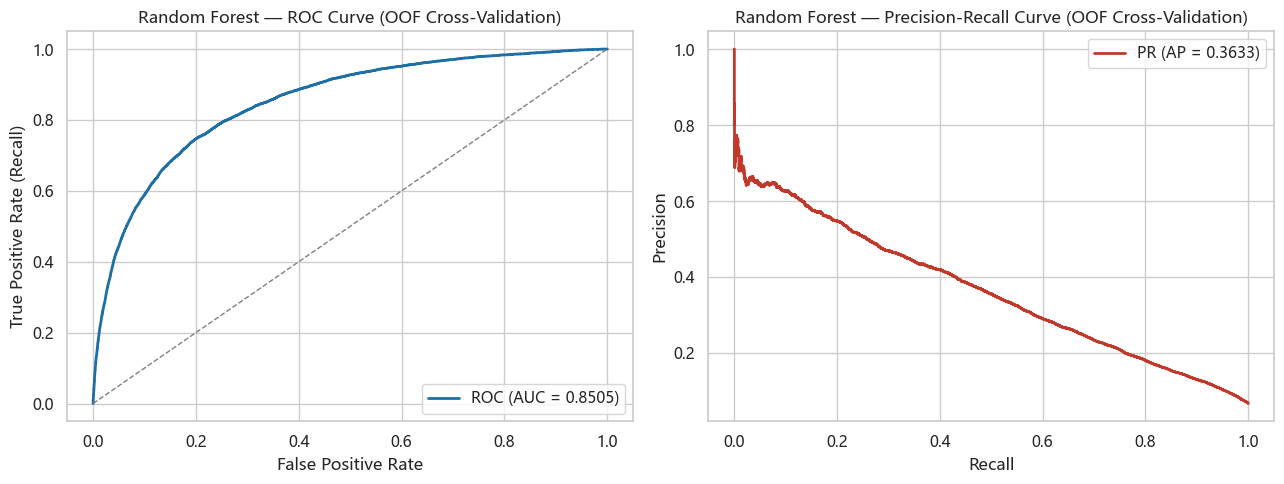

OOF ROC-AUC = 0.8505
OOF PR-AUC  = 0.3633

Note: ROC-AUC measures overall discriminative power (higher = better).
      PR-AUC is more informative under class imbalance (sensitive to minority class).


In [12]:
# ── Out-of-Fold 预测，用于绘制无偏 ROC / PR 曲线
# 注意：cross_val_predict 在每折内独立训练，结果不包含训练数据的信息泄露
print('Computing OOF (Out-of-Fold) probability predictions...')
rf_oof_proba = cross_val_predict(
    rf_best, X_train, y_train,
    cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]

# ── ROC 曲线
fpr, tpr, _ = roc_curve(y_train, rf_oof_proba)
roc_auc_cv  = auc(fpr, tpr)

# ── PR 曲线
precision, recall, _ = precision_recall_curve(y_train, rf_oof_proba)
pr_auc_cv = average_precision_score(y_train, rf_oof_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color='#1d6fa5', lw=2,
             label=f'ROC (AUC = {roc_auc_cv:.4f})')
axes[0].plot([0, 1], [0, 1], '--', color='gray', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('Random Forest — ROC Curve (OOF Cross-Validation)')
axes[0].legend(loc='lower right')

axes[1].plot(recall, precision, color='#c0392b', lw=2,
             label=f'PR (AP = {pr_auc_cv:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Random Forest — Precision-Recall Curve (OOF Cross-Validation)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f'OOF ROC-AUC = {roc_auc_cv:.4f}')
print(f'OOF PR-AUC  = {pr_auc_cv:.4f}')
print()
print('Note: ROC-AUC measures overall discriminative power (higher = better).')
print('      PR-AUC is more informative under class imbalance (sensitive to minority class).')

## 5. 特征重要性 | Feature Importance

Random Forest 使用 **平均不纯度减少**（Mean Decrease in Gini Impurity）来衡量特征重要性：  
每棵树中，某特征每次作为分裂依据时带来的 Gini 不纯度下降量的平均值。值越高说明该特征在分类中贡献越大。

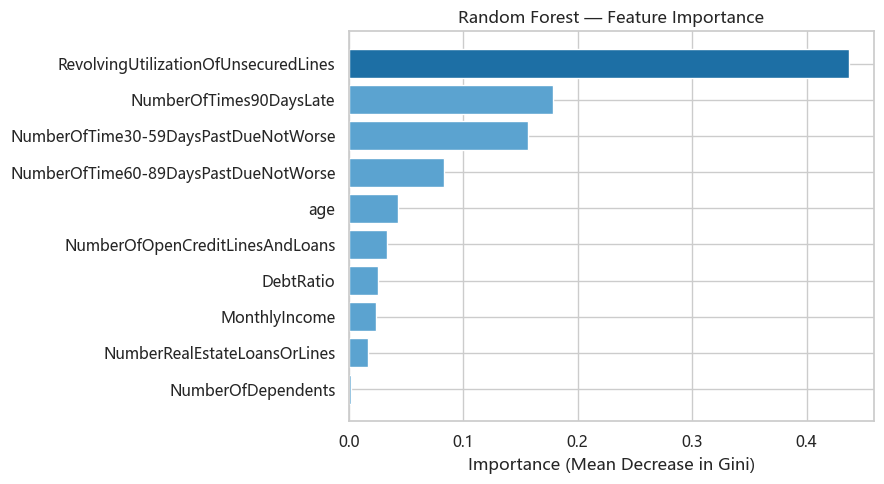

Feature importances (descending):


,feature,importance
0,RevolvingUtilizationOfUnsecuredLines,0.4370
1,NumberOfTimes90DaysLate,0.1781
2,NumberOfTime30-59DaysPastDueNotWorse,0.1567
3,NumberOfTime60-89DaysPastDueNotWorse,0.0832
4,age,0.0435
5,NumberOfOpenCreditLinesAndLoans,0.0335
6,DebtRatio,0.0256
7,MonthlyIncome,0.0237
8,NumberRealEstateLoansOrLines,0.0167
9,NumberOfDependents,0.0019


In [13]:
rf_clf = rf_best.named_steps['clf']   # 从 Pipeline 中取出分类器

importances = rf_clf.feature_importances_
imp_df = pd.DataFrame({
    'feature':    FEATURE_NAMES,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

# ── 可视化
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#1d6fa5' if i == 0 else '#5ba3d0' for i in range(len(imp_df))]
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Importance (Mean Decrease in Gini)')
ax.set_title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()

print('Feature importances (descending):')
display(imp_df.round(4))

## 6. 可解释性分析：SHAP 值 | SHAP Analysis

SHAP（SHapley Additive exPlanations）基于博弈论的 Shapley 值，为**每条样本的每个特征**分配一个贡献值：
- **正值（红色）**：该特征将违约概率推高
- **负值（蓝色）**：该特征将违约概率压低

相比 Gini 重要性，SHAP 能揭示**特征值大小与预测方向**的关系，解释性更强。

SHAP Beeswarm Plot (each dot = one sample):


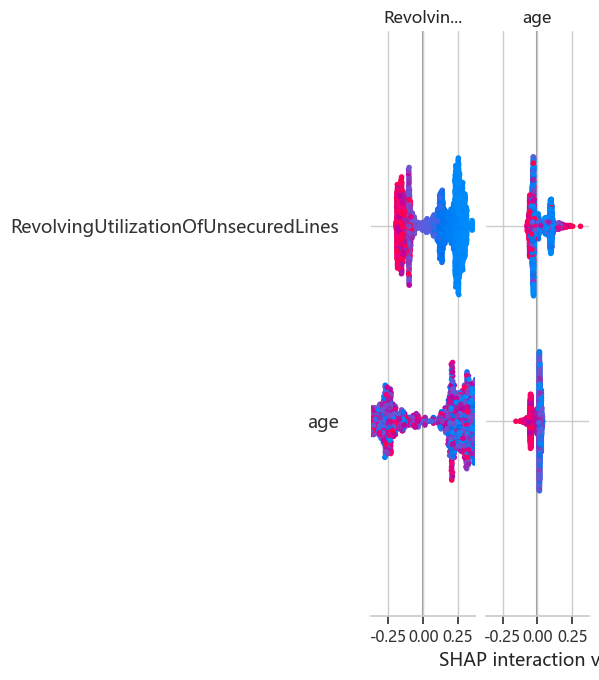

SHAP Bar Plot (mean |SHAP| value):


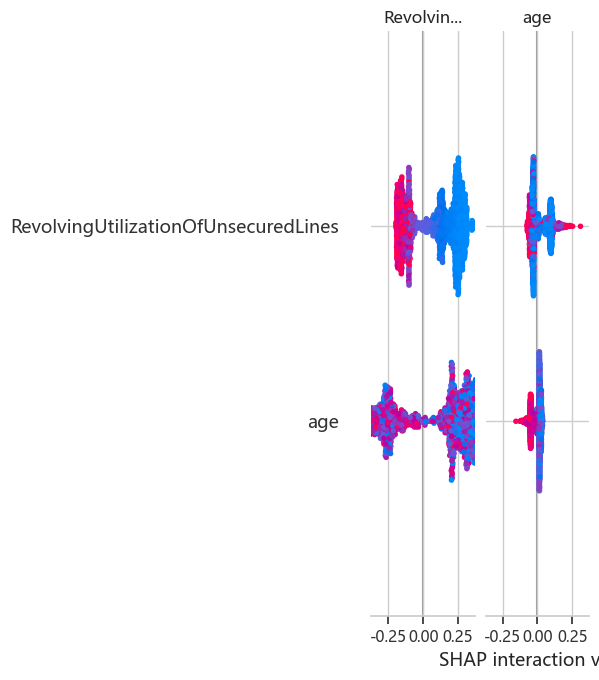

In [14]:
# 取 2000 个样本计算 SHAP（全量数据较慢）
shap_idx   = np.random.RandomState(RANDOM_STATE).choice(len(X_train), size=2000, replace=False)
X_shap     = X_train.iloc[shap_idx].reset_index(drop=True)

explainer   = shap.TreeExplainer(rf_clf)
shap_values = explainer.shap_values(X_shap)

# shap_values 是列表 [class_0, class_1]，取 class_1（违约）
shap_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values

# ── Beeswarm Plot：每个点是一个样本，颜色代表特征值高低
print('SHAP Beeswarm Plot (each dot = one sample):')
shap.summary_plot(shap_class1, X_shap, feature_names=FEATURE_NAMES,
                  plot_type='dot', show=True)

# ── Bar Plot：平均 |SHAP| 值，与特征重要性对比
print('SHAP Bar Plot (mean |SHAP| value):')
shap.summary_plot(shap_class1, X_shap, feature_names=FEATURE_NAMES,
                  plot_type='bar', show=True)

## 7. 测试集最终评估 | Final Test Set Evaluation

> ⚠️ 此单元格仅在完成全部训练和调参后运行一次。测试集结果代表模型在真实未见数据上的泛化性能（test error）。

  Random Forest — Final Test Set Results
  Accuracy : 0.7945
  ROC-AUC  : 0.8564
  PR-AUC   : 0.3686


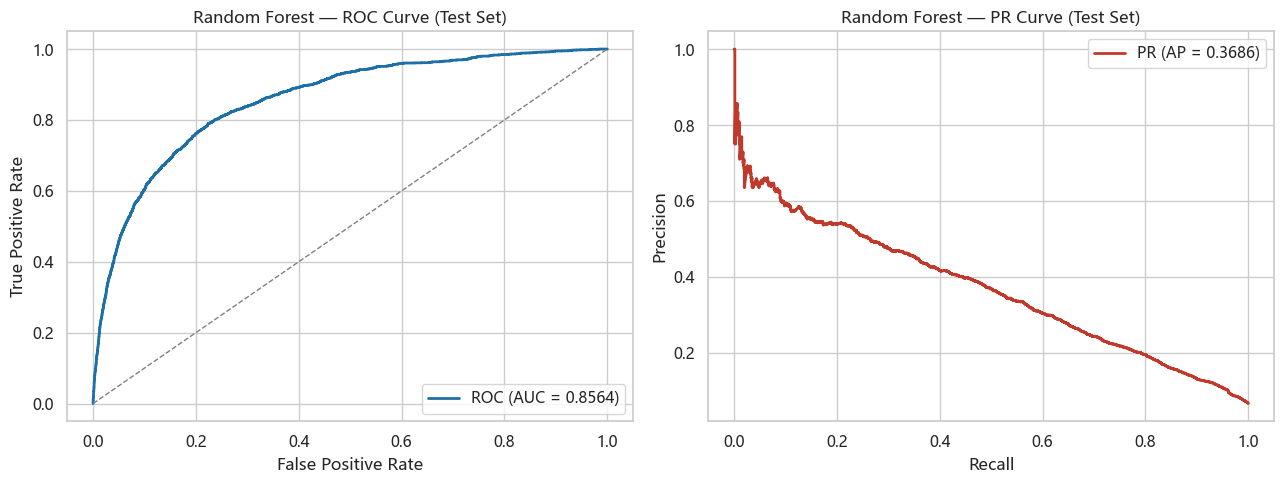

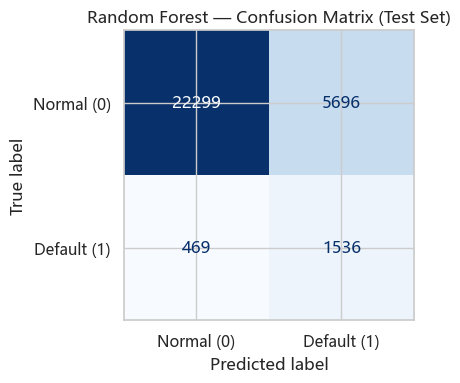

Classification Report:
              precision    recall  f1-score   support

  Normal (0)     0.9794    0.7965    0.8786     27995
 Default (1)     0.2124    0.7661    0.3326      2005

    accuracy                         0.7945     30000
   macro avg     0.5959    0.7813    0.6056     30000
weighted avg     0.9281    0.7945    0.8421     30000



In [15]:
y_pred  = rf_best.predict(X_test)
y_proba = rf_best.predict_proba(X_test)[:, 1]

test_acc     = accuracy_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_proba)
test_pr_auc  = average_precision_score(y_test, y_proba)

print('=' * 45)
print('  Random Forest — Final Test Set Results')
print('=' * 45)
print(f'  Accuracy : {test_acc:.4f}')
print(f'  ROC-AUC  : {test_roc_auc:.4f}')
print(f'  PR-AUC   : {test_pr_auc:.4f}')
print('=' * 45)

# ── ROC + PR 曲线
fpr_t, tpr_t, _ = roc_curve(y_test, y_proba)
prec_t, rec_t, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr_t, tpr_t, color='#1d6fa5', lw=2,
             label=f'ROC (AUC = {test_roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], '--', color='gray', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Random Forest — ROC Curve (Test Set)')
axes[0].legend(loc='lower right')

axes[1].plot(rec_t, prec_t, color='#c0392b', lw=2,
             label=f'PR (AP = {test_pr_auc:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Random Forest — PR Curve (Test Set)')
axes[1].legend(loc='upper right')
plt.tight_layout()
plt.show()

# ── 混淆矩阵
cm  = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Normal (0)', 'Default (1)']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

# ── 分类报告
print('Classification Report:')
print(classification_report(y_test, y_pred,
                             target_names=['Normal (0)', 'Default (1)'], digits=4))

## 8. 分析总结 | Summary

### 方法说明
- **数据拆分**：训练集:测试集 = 80:20，stratified sampling 保证类别分布一致
- **类别不平衡**：正负样本比约 1:14，Pipeline 中加入 SMOTE 过采样（每折独立执行）
- **交叉验证**：`StratifiedKFold(n_splits=5)`，以 ROC-AUC 为优化目标
- **超参数搜索**：GridSearchCV 穷举 `n_estimators / max_depth / min_samples_split / max_features`

### 主要挑战
1. **类别不平衡**：Accuracy 具有欺骗性（全预测 0 也能达到约 93%），应以 ROC-AUC 和 PR-AUC 为主要参考指标
2. **计算成本**：大样本（12 万）+ 多棵树 + GridSearchCV 计算量大，通过限制参数网格规模控制时间
3. **可解释性**：树模型的 Gini 重要性存在对高基数特征高估的问题，SHAP 值提供更可靠的特征贡献解释